# 第 12 章 · GAN

[章节网页](../ch12.html)

## 运行内容

- 运行判别器输出示例
- 绘制 D(x) 轨迹

## 0. 环境与数据

In [1]:
# 准备运行时：本 notebook 内嵌所需源码和数据，不依赖在线封装文件。
import importlib.util
import subprocess
import sys
from pathlib import Path

INLINE_RUNTIME_FILES = {
  "labs/ch12/create.py": "\"\"\"Chapter 12 creation demos — pedagogical API.\"\"\"\n\nfrom __future__ import annotations\n\nimport math\nimport random\n\nimport matplotlib.pyplot as plt\nimport numpy as np\n\n\ndef annealing_demo() -> None:\n    losses = [12.4, 8.1, 3.2, 2.3]\n    reprs = [\"代数\", \"代数+退火\", \"几何\", \"几何\"]\n    print(\"| 步骤 | 表征 | loss |\")\n    for i, (r, l) in enumerate(zip(reprs, losses)):\n        print(f\"| {i} | {r} | {l} |\")\n\n\ndef plot_annealing() -> None:\n    losses = [12.4, 8.1, 3.2, 2.3]\n    fig, ax = plt.subplots()\n    ax.plot(range(len(losses)), losses, marker=\"o\", color=\"#0d6b62\", linewidth=2)\n    ax.set_xlabel(\"search step\")\n    ax.set_ylabel(\"loss\")\n    ax.set_title(\"Annealing search\")\n    ax.grid(True, alpha=0.3)\n    plt.tight_layout()\n    plt.show()\n\n\ndef mcts_uct(q: float, n: int, N: int, c: float = 1.4) -> float:\n    if n == 0:\n        return float(\"inf\")\n    return q / n + c * math.sqrt(math.log(N + 1) / n)\n\n\ndef mcts_demo() -> None:\n    stats = {\"a\": (2, 5), \"b\": (3, 4)}\n    N = sum(n for _, n in stats.values())\n    print(\"UCT = Q/N + c·√(ln N / n):\")\n    for k, (q, n) in stats.items():\n        print(f\"  走法 {k}: Q={q}, n={n} → UCT={mcts_uct(q, n, N):.3f}\")\n\n\ndef plot_uct() -> None:\n    stats = {\"a\": (2, 5), \"b\": (3, 4), \"c\": (0, 0)}\n    N = sum(n for _, n in stats.values())\n    keys = list(stats.keys())\n    scores = [mcts_uct(q, n, N) for q, n in stats.values()]\n    fig, ax = plt.subplots()\n    ax.bar(keys, scores, color=\"#0d6b62\")\n    ax.set_title(\"MCTS UCT scores\")\n    plt.tight_layout()\n    plt.show()\n\n\ndef diffusion_1d() -> list[float]:\n    xs = diffusion_1d_values()\n    print(\"前向加噪 x:\", [round(v, 3) for v in xs])\n    return xs\n\n\ndef diffusion_1d_values(steps: int = 5, seed: int = 0, sigma: float = 0.3) -> list[float]:\n    random.seed(0)\n    if seed != 0:\n        random.seed(seed)\n    x0 = 1.0\n    xs = [x0]\n    x = x0\n    for _ in range(steps):\n        x += random.gauss(0, sigma)\n        xs.append(x)\n    return xs\n\n\ndef diffusion_1d_table(steps: int = 5, seed: int = 0, sigma: float = 0.3) -> None:\n    import pandas as pd\n    from IPython.display import display\n\n    xs = diffusion_1d_values(steps=steps, seed=seed, sigma=sigma)\n    display(pd.DataFrame({\"t\": list(range(len(xs))), \"x_t\": [round(v, 3) for v in xs]}))\n\n\ndef codelens_diffusion_1d(steps: int = 5) -> list:\n    from common.codelens import Frame\n\n    random.seed(0)\n    x = 1.0\n    frames = [Frame(0, \"x = x0\", \"初始\", {\"x\": round(x, 3)})]\n    for i in range(1, steps + 1):\n        x += random.gauss(0, 0.3)\n        frames.append(Frame(i, \"x += noise\", f\"第 {i} 步加噪\", {\"x\": round(x, 3)}))\n    return frames\n\n\ndef animate_diffusion_1d() -> None:\n    from common.viz_anim import animate_bar_values\n\n    frames = codelens_diffusion_1d()\n    snaps = [{\"step\": f.step, \"values\": {\"x\": f.state[\"x\"]}, \"action\": f.narrative} for f in frames]\n    animate_bar_values(snaps, title=\"1D diffusion x\", ylabel=\"x\", fps=0.8)\n\n\ndef plot_diffusion_1d(xs: list[float] | None = None) -> None:\n    if xs is None:\n        random.seed(0)\n        xs = [1.0]\n        x = 1.0\n        for _ in range(5):\n            x += random.gauss(0, 0.3)\n            xs.append(x)\n    fig, ax = plt.subplots()\n    ax.plot(range(len(xs)), xs, marker=\"o\", color=\"#3498db\", label=\"forward noise\")\n    ax.plot(range(len(xs)-1, -1, -1), xs[::-1], marker=\"x\", color=\"#0d6b62\", label=\"reverse denoise\")\n    ax.set_title(\"1D diffusion toy\")\n    ax.legend()\n    ax.grid(True, alpha=0.3)\n    plt.tight_layout()\n    plt.show()\n\n\ndef _digits_sample(digit: int = 3) -> tuple[np.ndarray, np.ndarray, int]:\n    from sklearn.datasets import load_digits\n\n    digits = load_digits()\n    images = digits.images.astype(float) / 16.0\n    labels = digits.target\n    idx = int(np.where(labels == digit)[0][3])\n    prototype = images[labels == digit].mean(axis=0)\n    return images[idx], prototype, int(labels[idx])\n\n\ndef _diffusion_schedule(steps: int = 6) -> tuple[np.ndarray, np.ndarray]:\n    betas = np.linspace(0.06, 0.24, steps)\n    alpha_bar = np.cumprod(1.0 - betas)\n    return betas, alpha_bar\n\n\ndef digits_diffusion_table(steps: int = 6) -> None:\n    import pandas as pd\n    from IPython.display import display\n\n    betas, alpha_bar = _diffusion_schedule(steps)\n    rows = []\n    for t, (beta, abar) in enumerate(zip(betas, alpha_bar), start=1):\n        rows.append(\n            {\n                \"t\": t,\n                \"beta_t\": round(float(beta), 3),\n                \"signal_scale sqrt(alpha_bar)\": round(float(np.sqrt(abar)), 3),\n                \"noise_scale sqrt(1-alpha_bar)\": round(float(np.sqrt(1 - abar)), 3),\n            }\n        )\n    display(pd.DataFrame(rows))\n\n\ndef make_digits_diffusion(seed: int = 7, digit: int = 3, steps: int = 6) -> dict:\n    rng = np.random.default_rng(seed)\n    image, prototype, label = _digits_sample(digit)\n    betas, alpha_bar = _diffusion_schedule(steps)\n    noise = rng.normal(0, 1, size=image.shape)\n\n    forward = [image]\n    for abar in alpha_bar:\n        xt = np.sqrt(abar) * image + np.sqrt(1 - abar) * noise\n        forward.append(np.clip(xt, 0, 1))\n\n    reverse = [forward[-1]]\n    x = forward[-1]\n    # A tiny teaching denoiser: use the class prototype as a stand-in for a learned score model.\n    for t in range(steps, 0, -1):\n        blend = 0.18 + 0.09 * (steps - t)\n        x = (1 - blend) * x + blend * prototype\n        x = np.clip(x, 0, 1)\n        reverse.append(x)\n\n    return {\n        \"label\": label,\n        \"image\": image,\n        \"prototype\": prototype,\n        \"forward\": forward,\n        \"reverse\": reverse,\n        \"betas\": betas,\n        \"alpha_bar\": alpha_bar,\n    }\n\n\ndef plot_digits_forward(seed: int = 7, digit: int = 3) -> None:\n    data = make_digits_diffusion(seed=seed, digit=digit)\n    frames = data[\"forward\"]\n    fig, axes = plt.subplots(1, len(frames), figsize=(1.55 * len(frames), 1.8))\n    for i, (ax, img) in enumerate(zip(axes, frames)):\n        ax.imshow(img, cmap=\"gray\", vmin=0, vmax=1)\n        ax.set_title(\"x0\" if i == 0 else f\"x{i}\")\n        ax.axis(\"off\")\n    fig.suptitle(f\"Forward diffusion on sklearn digits: label {data['label']}\", y=1.05)\n    plt.tight_layout()\n    plt.show()\n\n\ndef plot_digits_reverse(seed: int = 7, digit: int = 3) -> None:\n    data = make_digits_diffusion(seed=seed, digit=digit)\n    frames = data[\"reverse\"]\n    fig, axes = plt.subplots(1, len(frames), figsize=(1.55 * len(frames), 1.8))\n    for i, (ax, img) in enumerate(zip(axes, frames)):\n        ax.imshow(img, cmap=\"gray\", vmin=0, vmax=1)\n        ax.set_title(\"noise\" if i == 0 else f\"rev {i}\")\n        ax.axis(\"off\")\n    fig.suptitle(\"Reverse denoising path with a class-prototype denoiser\", y=1.05)\n    plt.tight_layout()\n    plt.show()\n\n\ndef plot_digits_denoiser_comparison(seed: int = 7, digit: int = 3) -> None:\n    data = make_digits_diffusion(seed=seed, digit=digit)\n    images = [data[\"image\"], data[\"forward\"][-1], data[\"prototype\"], data[\"reverse\"][-1]]\n    titles = [\"clean x0\", \"noisy xT\", \"class prototype\", \"denoised\"]\n    fig, axes = plt.subplots(1, 4, figsize=(7.2, 2.1))\n    for ax, img, title in zip(axes, images, titles):\n        ax.imshow(img, cmap=\"gray\", vmin=0, vmax=1)\n        ax.set_title(title)\n        ax.axis(\"off\")\n    plt.tight_layout()\n    plt.show()\n\n\ndef digits_diffusion_summary(seed: int = 7, digit: int = 3) -> None:\n    data = make_digits_diffusion(seed=seed, digit=digit)\n    clean = data[\"image\"]\n    noisy = data[\"forward\"][-1]\n    denoised = data[\"reverse\"][-1]\n    print(f\"digit label: {data['label']}\")\n    print(f\"MSE(noisy, clean)   = {np.mean((noisy - clean) ** 2):.4f}\")\n    print(f\"MSE(denoised, clean)= {np.mean((denoised - clean) ** 2):.4f}\")\n    print(\"这个 notebook 用类原型代替真实神经网络，目的是展示经典图像 diffusion 的过程缩影。\")\n\n\ndef gan_toy() -> None:\n    d_fake = [0.18, 0.08, 0.74, 0.50]\n    print(\"D(生成样本) 概率:\", \" → \".join(f\"{v:.2f}\" for v in d_fake))\n\n\ndef plot_gan_d() -> None:\n    d_fake = [0.18, 0.08, 0.74, 0.50]\n    fig, ax = plt.subplots()\n    ax.plot(range(len(d_fake)), d_fake, marker=\"o\", color=\"#e74c3c\", linewidth=2)\n    ax.axhline(0.5, color=\"gray\", linestyle=\"--\", label=\"ideal D=0.5\")\n    ax.set_title(\"GAN discriminator D(x)\")\n    ax.legend()\n    ax.grid(True, alpha=0.3)\n    plt.tight_layout()\n    plt.show()\n\n\ndef alphafold_outline() -> None:\n    steps = [\"输入氨基酸序列\", \"MSA 共变\", \"Evoformer\", \"3D 坐标 + pLDDT\"]\n    for i, s in enumerate(steps):\n        print(f\"{i+1}. {s}\")\n",
  "labs/common/campus_graph.json": "{\n  \"goal\": \"c1\",\n  \"start\": \"x\",\n  \"nodes\": {\n    \"x\": { \"name\": \"校门口\", \"h\": 7 },\n    \"c2\": { \"name\": \"超市\", \"h\": 1 },\n    \"j\": { \"name\": \"教学楼\", \"h\": 4 },\n    \"s2\": { \"name\": \"实验楼\", \"h\": 4 },\n    \"s1\": { \"name\": \"食堂\", \"h\": 3 },\n    \"t\": { \"name\": \"图书馆\", \"h\": 2 },\n    \"c1\": { \"name\": \"操场\", \"h\": 0 }\n  },\n  \"edges\": [\n    { \"from\": \"x\", \"to\": \"c2\", \"cost\": 7 },\n    { \"from\": \"x\", \"to\": \"j\", \"cost\": 2 },\n    { \"from\": \"x\", \"to\": \"s1\", \"cost\": 2 },\n    { \"from\": \"j\", \"to\": \"s2\", \"cost\": 4 },\n    { \"from\": \"s2\", \"to\": \"s1\", \"cost\": 1 },\n    { \"from\": \"s1\", \"to\": \"t\", \"cost\": 3 },\n    { \"from\": \"s1\", \"to\": \"c1\", \"cost\": 6 },\n    { \"from\": \"t\", \"to\": \"c1\", \"cost\": 2 }\n  ],\n  \"expected\": {\n    \"dfs\": { \"path\": [\"x\", \"j\", \"s2\", \"s1\", \"c1\"], \"steps\": 4, \"cost\": 13 },\n    \"bfs\": { \"path\": [\"x\", \"s1\", \"c1\"], \"steps\": 2, \"cost\": 8 },\n    \"ucs\": { \"path\": [\"x\", \"s1\", \"t\", \"c1\"], \"steps\": 3, \"cost\": 7 },\n    \"greedy\": { \"path\": [\"x\", \"s1\", \"c1\"], \"steps\": 2, \"cost\": 8 },\n    \"astar\": { \"path\": [\"x\", \"s1\", \"t\", \"c1\"], \"steps\": 3, \"cost\": 7 }\n  }\n}\n",
  "labs/common/ch6_kg.json": "{\n  \"nodes\": [\"鲁迅\", \"狂人日记\", \"呐喊\", \"文学周报社\", \"茅盾文学奖\", \"莫言\", \"蛙\", \"红高粱\", \"典藏\", \"电影\", \"金熊奖\"],\n  \"edges\": [\n    [\"鲁迅\", \"创作\", \"狂人日记\"],\n    [\"鲁迅\", \"创作\", \"呐喊\"],\n    [\"狂人日记\", \"发表于\", \"文学周报社\"],\n    [\"呐喊\", \"发表于\", \"文学周报社\"],\n    [\"狂人日记\", \"获得\", \"茅盾文学奖\"],\n    [\"莫言\", \"创作\", \"蛙\"],\n    [\"莫言\", \"创作\", \"红高粱\"],\n    [\"蛙\", \"获得\", \"茅盾文学奖\"],\n    [\"红高粱\", \"入选\", \"典藏\"],\n    [\"红高粱\", \"改编\", \"电影\"],\n    [\"电影\", \"获得\", \"金熊奖\"]\n  ],\n  \"query\": {\n    \"pattern\": [\"鲁迅\", \"创作\", \"?X\", \"?X\", \"发表于\", \"?Y\"],\n    \"answer_y\": \"文学周报社\"\n  },\n  \"path_scores\": {\n    \"蛙→茅盾文学奖\": 3,\n    \"红高粱→典藏\": 2,\n    \"红高粱→电影→金熊奖\": 3\n  }\n}\n",
  "labs/common/ch6_rules.json": "{\n  \"facts\": [\"人(苏格拉底)\"],\n  \"rules\": [\n    { \"id\": \"R1\", \"if\": [\"人(X)\"], \"then\": \"会死(X)\" },\n    { \"id\": \"R2\", \"if\": [\"会死(X)\"], \"then\": \"终有一死(X)\" }\n  ],\n  \"goal\": \"终有一死(苏格拉底)\"\n}\n",
  "labs/common/codelens.py": "\"\"\"CodeLens-style execution frames — print every variable change.\"\"\"\n\nfrom __future__ import annotations\n\nfrom dataclasses import dataclass, field\nfrom typing import Any\n\n\n@dataclass\nclass Frame:\n    step: int\n    line: str\n    narrative: str\n    state: dict[str, Any] = field(default_factory=dict)\n\n    def print(self) -> None:\n        print(f\"── Step {self.step} ── {self.narrative}\")\n        print(f\"   执行: {self.line}\")\n        for k, v in self.state.items():\n            print(f\"   {k} = {v!r}\")\n\n\ndef print_frames(frames: list[Frame], start: int = 0, stop: int | None = None) -> None:\n    for f in frames[start:stop]:\n        f.print()\n        print()\n\n\ndef frames_to_table(frames: list[Frame], keys: list[str]) -> \"pd.DataFrame\":\n    import pandas as pd\n\n    rows = []\n    for f in frames:\n        row = {\"步\": f.step, \"说明\": f.narrative}\n        for k in keys:\n            row[k] = f.state.get(k, \"\")\n        rows.append(row)\n    return pd.DataFrame(rows)\n",
  "labs/common/luxun_bpe.json": "{\n  \"corpus_hint\": \"鲁迅 写 了 狂人 日记\",\n  \"initial_tokens\": [\"鲁\", \"迅\", \"写\", \"了\", \"狂\", \"人\", \"日\", \"记\"],\n  \"merges\": [\n    { \"pair\": [\"日\", \"记\"], \"count\": 12, \"result\": \"日记\", \"tokens_after\": [\"鲁\", \"迅\", \"写\", \"了\", \"狂\", \"人\", \"日记\"] },\n    { \"pair\": [\"狂\", \"人\"], \"count\": 8, \"result\": \"狂人\", \"tokens_after\": [\"鲁\", \"迅\", \"写\", \"了\", \"狂人\", \"日记\"] },\n    { \"pair\": [\"鲁\", \"迅\"], \"count\": 6, \"result\": \"鲁迅\", \"tokens_after\": [\"鲁迅\", \"写\", \"了\", \"狂人\", \"日记\"] }\n  ],\n  \"final_tokens\": [\"鲁迅\", \"写\", \"了\", \"狂人\", \"日记\"]\n}\n",
  "labs/common/mpl_setup.py": "\"\"\"Matplotlib font setup for notebook figures.\"\"\"\n\nfrom __future__ import annotations\n\nimport logging\nimport warnings\nfrom pathlib import Path\n\nimport matplotlib as mpl\nimport matplotlib.font_manager as fm\n\n# Prefer one fixed CJK face in rendered site; keep local fallbacks for downloaded notebooks.\nCJK_FONT = \"Noto Sans CJK SC\"\n\n_FONT_PATHS = [\n    \"/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc\",\n    \"/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc\",\n    \"/usr/share/fonts/truetype/noto/NotoSansCJK-Regular.ttc\",\n    \"/System/Library/Fonts/PingFang.ttc\",\n    \"/System/Library/Fonts/STHeiti Light.ttc\",\n    \"/Library/Fonts/Arial Unicode.ttf\",\n]\n\n_CJK_NAMES = [\n    CJK_FONT,\n    \"Noto Sans SC\",\n    \"Source Han Sans SC\",\n    \"PingFang SC\",\n    \"Heiti SC\",\n    \"STHeiti\",\n    \"Arial Unicode MS\",\n    \"WenQuanYi Micro Hei\",\n]\n\n_CONFIGURED = False\n\n\ndef _register_font_files() -> str | None:\n    registered: list[str] = []\n    for path in _FONT_PATHS:\n        p = Path(path)\n        if not p.is_file():\n            continue\n        try:\n            fm.fontManager.addfont(str(p))\n            prop = fm.FontProperties(fname=str(p))\n            name = prop.get_name()\n            if name and name not in registered:\n                registered.append(name)\n        except Exception:\n            continue\n    return registered[0] if registered else None\n\n\ndef _find_cjk_font() -> str | None:\n    from_file = _register_font_files()\n    available = {f.name for f in fm.fontManager.ttflist}\n    if CJK_FONT in available:\n        return CJK_FONT\n    if from_file:\n        return from_file\n    for name in _CJK_NAMES:\n        if name in available:\n            return name\n    return None\n\n\ndef configure_matplotlib() -> None:\n    \"\"\"Notebook 首个绘图 cell 前调用一次。\"\"\"\n    global _CONFIGURED\n    if _CONFIGURED:\n        return\n    _CONFIGURED = True\n\n    logging.getLogger(\"matplotlib.font_manager\").setLevel(logging.ERROR)\n    warnings.filterwarnings(\"ignore\", message=\".*Glyph.*missing from font.*\")\n    warnings.filterwarnings(\"ignore\", message=\".*findfont.*\")\n\n    name = _find_cjk_font()\n    if name:\n        mpl.rcParams[\"font.sans-serif\"] = [name, \"DejaVu Sans\", \"sans-serif\"]\n        mpl.rcParams[\"font.family\"] = \"sans-serif\"\n    else:\n        mpl.rcParams[\"font.sans-serif\"] = [\"DejaVu Sans\", \"sans-serif\"]\n    mpl.rcParams[\"axes.unicode_minus\"] = False\n    mpl.rcParams[\"figure.dpi\"] = 100\n    mpl.rcParams[\"mathtext.default\"] = \"regular\"\n\n\ndef ascii_plot(text: str) -> str:\n    \"\"\"把常见数学符号换成 DejaVu 可显示的 ASCII（用于轴标签/GIF）。\"\"\"\n    repl = {\n        \"α\": \"alpha\",\n        \"β\": \"beta\",\n        \"γ\": \"gamma\",\n        \"δ\": \"delta\",\n        \"ε\": \"eps\",\n        \"σ\": \"sigma\",\n        \"ŷ\": \"y_hat\",\n        \"₁\": \"1\",\n        \"₂\": \"2\",\n        \"₃\": \"3\",\n        \"→\": \"->\",\n    }\n    out = text\n    for k, v in repl.items():\n        out = out.replace(k, v)\n    return out\n",
  "labs/common/notebook_helpers.py": "\"\"\"Shared helpers for pedagogical notebooks.\"\"\"\n\nfrom __future__ import annotations\n\nimport textwrap\nfrom pathlib import Path\n\nimport matplotlib.pyplot as plt\nimport numpy as np\nimport pandas as pd\n\n# Keep helper plots aligned with the rendered notebook font.\nplt.rcParams.update(\n    {\n        \"figure.figsize\": (7.5, 4.2),\n        \"font.size\": 11,\n        \"axes.unicode_minus\": False,\n        \"font.family\": \"sans-serif\",\n        \"font.sans-serif\": [\"Noto Sans CJK SC\", \"DejaVu Sans\", \"sans-serif\"],\n    }\n)\n\n\ndef repo_root() -> Path:\n    cwd = Path.cwd()\n    if (cwd / \"labs\").exists():\n        return cwd\n    if (cwd.parent / \"labs\").exists():\n        return cwd.parent\n    return cwd\n\n\nBOOTSTRAP = textwrap.dedent(\n    \"\"\"\n    import sys\n    from pathlib import Path\n    ROOT = Path.cwd()\n    if not (ROOT / \"labs\").exists() and (ROOT.parent / \"labs\").exists():\n        ROOT = ROOT.parent\n    if str(ROOT) not in sys.path:\n        sys.path.insert(0, str(ROOT))\n    \"\"\"\n).strip()\n\n\ndef bootstrap_code(extra: str = \"\") -> str:\n    return BOOTSTRAP + (\"\\n\" + extra.strip() if extra.strip() else \"\")\n\n\ndef show_df(df: pd.DataFrame, title: str = \"\") -> None:\n    if title:\n        print(title)\n    print(df.to_string(index=False))\n\n\ndef plot_line_series(\n    xs: list,\n    ys: list,\n    *,\n    title: str,\n    xlabel: str = \"\",\n    ylabel: str = \"\",\n    markers: bool = True,\n) -> None:\n    fig, ax = plt.subplots()\n    ax.plot(xs, ys, marker=\"o\" if markers else None, linewidth=2)\n    ax.set_title(title)\n    if xlabel:\n        ax.set_xlabel(xlabel)\n    if ylabel:\n        ax.set_ylabel(ylabel)\n    ax.grid(True, alpha=0.3)\n    plt.tight_layout()\n    plt.show()\n\n\ndef plot_scatter_labeled(\n    points: np.ndarray,\n    labels: np.ndarray | None,\n    *,\n    title: str,\n    label_names: dict[int, str] | None = None,\n) -> None:\n    fig, ax = plt.subplots()\n    if labels is None:\n        ax.scatter(points[:, 0], points[:, 1], s=60, c=\"#0d6b62\")\n    else:\n        for lab in np.unique(labels):\n            mask = labels == lab\n            name = (label_names or {}).get(int(lab), f\"类 {lab}\")\n            ax.scatter(points[mask, 0], points[mask, 1], s=60, label=name)\n        ax.legend()\n    ax.set_title(title)\n    ax.grid(True, alpha=0.3)\n    plt.tight_layout()\n    plt.show()\n"
}

ROOT = Path.cwd() / "_ai_thinking_labs_inline_runtime"
for rel, source in INLINE_RUNTIME_FILES.items():
    target = ROOT / rel
    target.parent.mkdir(parents=True, exist_ok=True)
    target.write_text(source, encoding="utf-8")

missing = []
for module, package in [
    ("numpy", "numpy>=1.24"),
    ("pandas", "pandas>=2.0"),
    ("matplotlib", "matplotlib>=3.7"),
    ("scipy", "scipy>=1.10"),
    ("sklearn", "scikit-learn>=1.3"),
]:
    if importlib.util.find_spec(module) is None:
        missing.append(package)
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "labs"))
sys.path.insert(0, str(ROOT / "labs" / "ch12"))
import matplotlib.pyplot as plt
from common.mpl_setup import configure_matplotlib
configure_matplotlib()
from IPython.display import display, Image
print("runtime ready:", ROOT)
from create import *

runtime ready: /Users/zhesun/Desktop/Fudan/phd/vibe coding/notebooks/_ai_thinking_labs_inline_runtime


In [2]:
# 运行 GAN 判别器输出的玩具轨迹。
gan_toy()

D(生成样本) 概率: 0.18 → 0.08 → 0.74 → 0.50


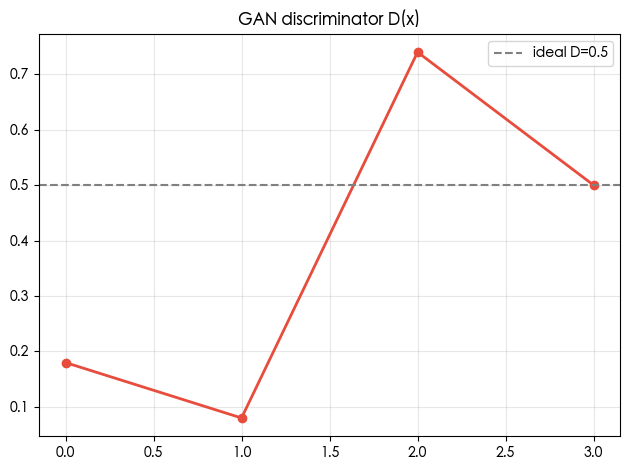

In [3]:
# 绘制 D(生成样本) 的变化。
plot_gan_d()